In [15]:
import pandas as pd

# Load the dataset
dataset = pd.read_csv('legal_text_classification.csv')

# Display the first few rows of the dataset
dataset.head()


,case_id,case_outcome,case_title,case_text
0,Case15689,cited,Knight v Beyond Properties Pty Ltd [2007] FCAF...,Relevant principles in the context of claimed ...
1,Case9347,applied,Powell v Evreniades (1989) 21 FCR 252,The term 'serious hardship' is not defined in ...
2,Case8483,cited,Wigan v English and Scottish Law Life Assuranc...,to sue for an antecedent debt pursuant to an a...
3,Case11187,cited,Roufos v Andrea (1981) 57 FLR 10,In determining whether a bankruptcy notice cou...
4,Case1695,applied,Alister v The Queen (1984) 154 CLR 404,Commonwealth v Northern Land Council [1993] HC...


In [17]:
dataset.isnull().sum()


case_id          0
case_outcome     0
case_title       0
case_text       76
dtype: int64

In [19]:
dataset.info()
dataset.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       12000 non-null  object
 1   case_outcome  12000 non-null  object
 2   case_title    12000 non-null  object
 3   case_text     11924 non-null  object
dtypes: object(4)
memory usage: 375.1+ KB


,case_id,case_outcome,case_title,case_text
count,12000,12000,12000,11924
unique,12000,10,9852,9855
top,Case15689,cited,Minister for Immigration and Ethnic Affairs v ...,submitted that this Court should hold that the...
freq,1,5908,36,20


In [21]:
# Drop rows with missing case_text
dataset.dropna(subset=['case_text'], inplace=True)


In [23]:
# Analyze the distribution of case outcomes
dataset['case_outcome'].value_counts()


case_outcome
cited            5861
referred to      2095
applied          1180
followed         1029
considered        817
discussed         492
distinguished     287
affirmed           58
related            55
approved           50
Name: count, dtype: int64

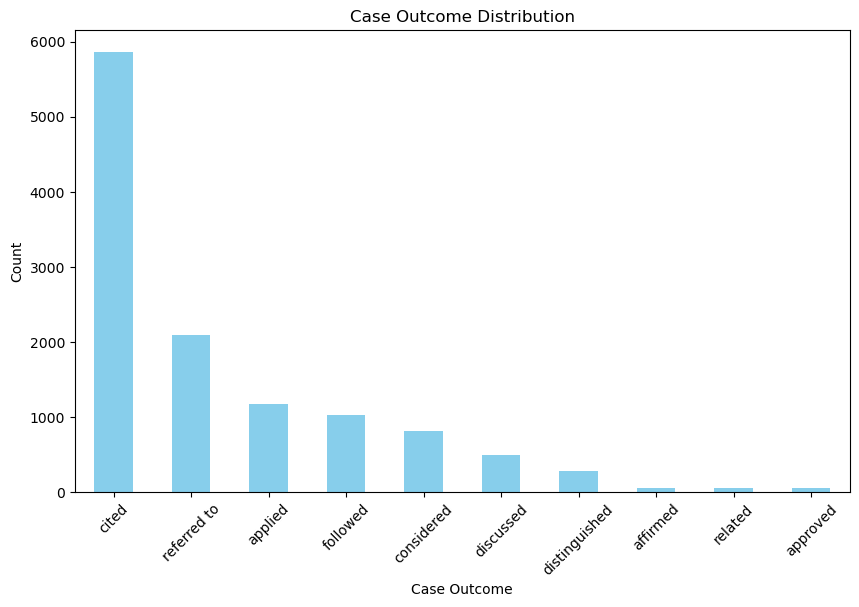

In [25]:
import matplotlib.pyplot as plt

# Bar chart for case outcome distribution
dataset['case_outcome'].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Case Outcome Distribution')
plt.xlabel('Case Outcome')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


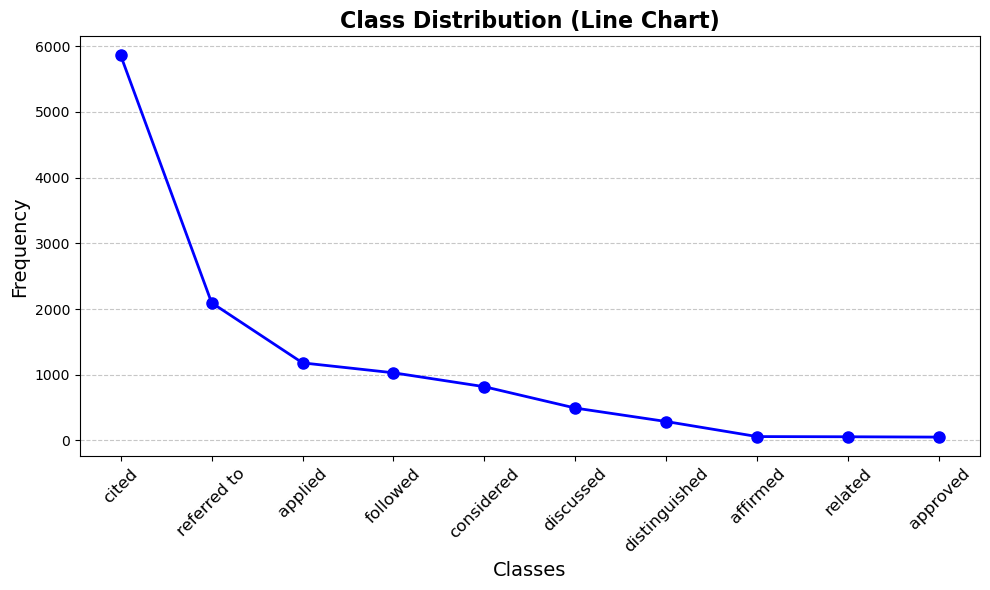

In [27]:
import matplotlib.pyplot as plt

# Calculate the class distribution
class_distribution = dataset['case_outcome'].value_counts()

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(
    class_distribution.index, 
    class_distribution.values, 
    marker='o', 
    linestyle='-', 
    color='blue', 
    linewidth=2, 
    markersize=8
)

# Add titles and labels
plt.title("Class Distribution (Line Chart)", fontsize=16, weight='bold')
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.tight_layout()

# Show the plot
plt.show()


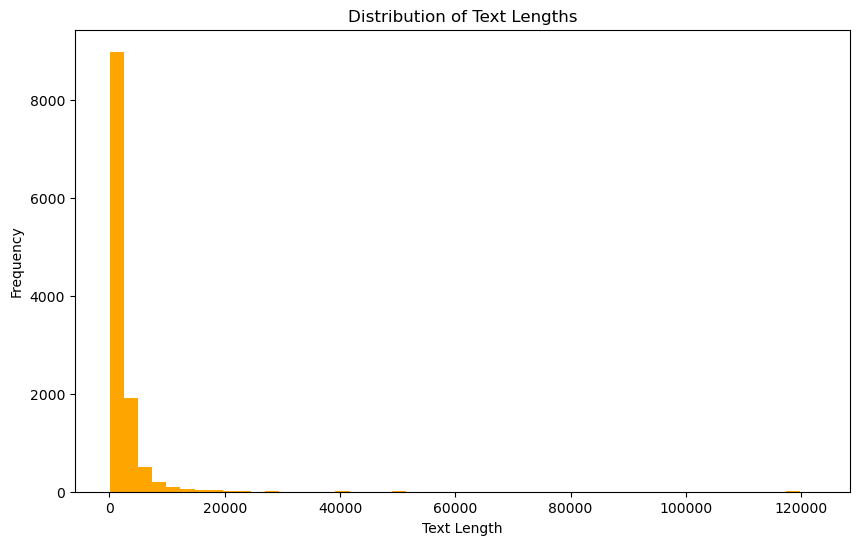

In [29]:
# Add a column for text lengths
dataset['text_length'] = dataset['case_text'].apply(len)

# Visualize the distribution of text lengths
dataset['text_length'].plot(kind='hist', bins=50, figsize=(10, 6), color='orange')
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()


In [31]:
#average text length
# Calculate the length of each case text
dataset['text_length'] = dataset['case_text'].apply(len)

# Calculate the average text length
average_text_length = dataset['text_length'].mean()

# Print the average text length
print(f"Average Text Length: {average_text_length:.2f}")


Average Text Length: 2627.40


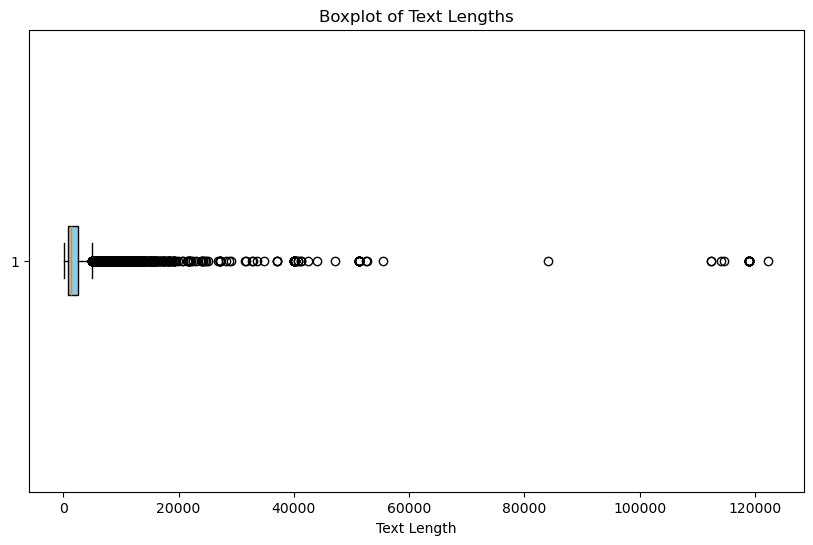

In [33]:
import matplotlib.pyplot as plt

# Create a boxplot for text lengths
plt.figure(figsize=(10, 6))
plt.boxplot(dataset['text_length'], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Boxplot of Text Lengths')
plt.xlabel('Text Length')
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ZAID\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


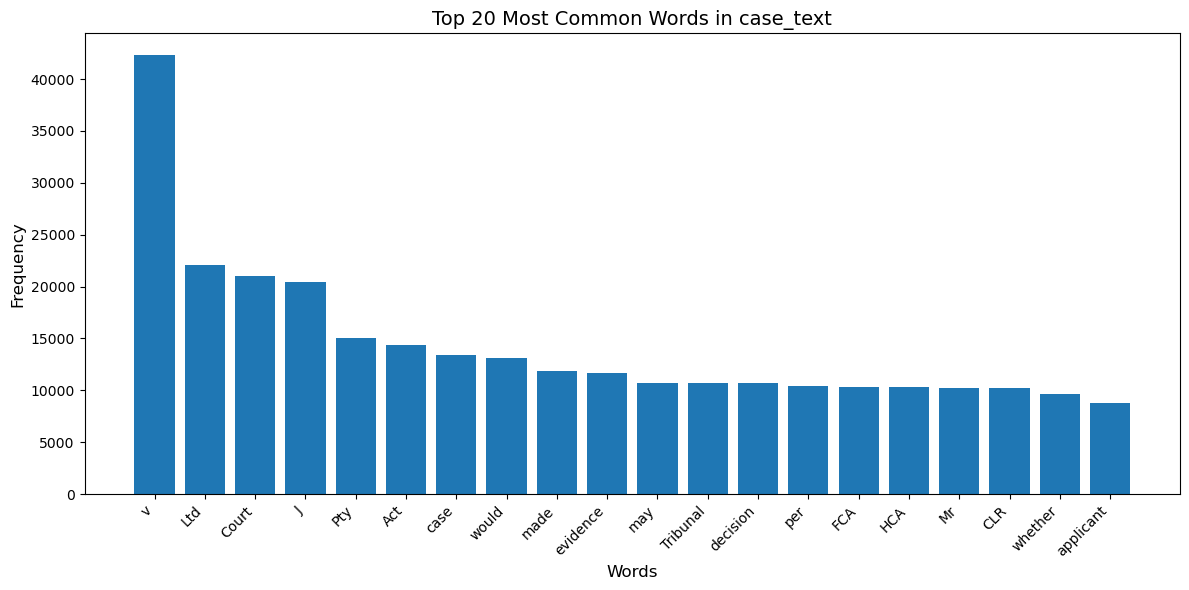

In [40]:
#After removing stopwords

import re

import matplotlib.pyplot as plt
from collections import Counter

dataset_copy = dataset.copy()
dataset_copy['case_text'] = dataset_copy['case_text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))  # Remove non-alphabetic characters

import nltk
from nltk.corpus import stopwords

# Ensure the NLTK stopwords dataset is downloaded
nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stop words
def remove_stopwords(text):
    words = text.split()  # Split the text into words
    filtered_words = [word for word in words if word.lower() not in stop_words]  # Remove stop words
    return ' '.join(filtered_words)  # Join words back into a string

#Apply cleaning and stopword removal
dataset_copy['case_text'] = dataset_copy['case_text'].apply(remove_stopwords)  # Remove stopwords

# Flatten all the words into a single list
all_words = ' '.join(dataset_copy['case_text']).split()

# Count the occurrences of each word
word_counts = Counter(all_words)

# Get the most common words and their counts
most_common_words = word_counts.most_common(20)  # Top 20 words

# Split the words and counts for plotting
words, counts = zip(*most_common_words)

# Plot the most common words
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title('Top 20 Most Common Words in case_text', fontsize=14)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [41]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


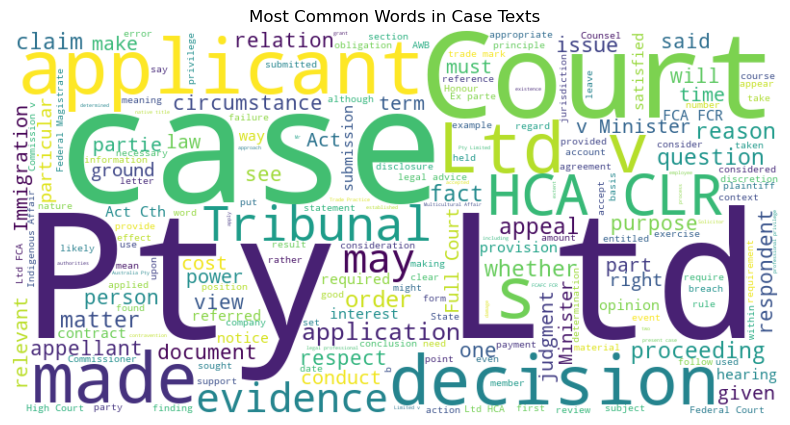

In [42]:
from wordcloud import WordCloud

# Generate a word cloud
text = ' '.join(dataset['case_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Case Texts')
plt.show()


In [44]:
dataset['case_text'] = dataset['case_text'].str.lower()


In [46]:
import re

dataset['case_text'] = dataset['case_text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))  # Remove non-alphabetic characters

# import nltk
# from nltk.corpus import stopwords

# # Ensure the NLTK stopwords dataset is downloaded
# nltk.download('stopwords')

# # Get the list of English stopwords
# stop_words = set(stopwords.words('english'))

# # Function to remove stop words
# def remove_stopwords(text):
#     words = text.split()  # Split the text into words
#     filtered_words = [word for word in words if word.lower() not in stop_words]  # Remove stop words
#     return ' '.join(filtered_words)  # Join words back into a string

# Apply cleaning and stopword removal
# dataset['case_text'] = dataset['case_text'].apply(remove_stopwords)  # Remove stopwords


In [47]:
dataset.head()


,case_id,case_outcome,case_title,case_text,text_length
0,Case15689,cited,Knight v Beyond Properties Pty Ltd [2007] FCAF...,relevant principles in the context of claimed ...,3444
1,Case9347,applied,Powell v Evreniades (1989) 21 FCR 252,the term serious hardship is not defined in th...,7278
2,Case8483,cited,Wigan v English and Scottish Law Life Assuranc...,to sue for an antecedent debt pursuant to an a...,1068
3,Case11187,cited,Roufos v Andrea (1981) 57 FLR 10,in determining whether a bankruptcy notice cou...,476
4,Case1695,applied,Alister v The Queen (1984) 154 CLR 404,commonwealth v northern land council hca ...,7134


In [52]:
# Distribution of case outcomes
dataset['case_outcome'].value_counts()


case_outcome
cited            5861
referred to      2095
applied          1180
followed         1029
considered        817
discussed         492
distinguished     287
affirmed           58
related            55
approved           50
Name: count, dtype: int64

In [60]:
from sklearn.utils import resample

# Separate majority and minority classes
majority = dataset[dataset['case_outcome'] == 'cited']  # Replace 'cited' with the dominant class
minority = dataset[dataset['case_outcome'] != 'cited']  # Replace '!= cited' with other classes

# Upsample minority classes
minority_upsampled = resample(minority, 
                              replace=True,     # Sample with replacement
                              n_samples=len(majority),  # Match majority class size
                              random_state=42) # For reproducibility

# Combine back into a balanced dataset
balanced_dataset = pd.concat([majority, minority_upsampled])

# Verify the class distribution
print(balanced_dataset['case_outcome'].value_counts())


case_outcome
cited            5861
referred to      2092
applied          1127
followed          949
considered        805
discussed         472
distinguished     294
related            46
affirmed           42
approved           34
Name: count, dtype: int64


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer (You can adjust max_features to control the number of features)
tfidf = TfidfVectorizer(max_features=5000)  # Limit to 5000 features for simplicity

# Transform the case_text column into TF-IDF features
X = tfidf.fit_transform(dataset['case_text'])

# Check the shape of the resulting TF-IDF matrix
print(X.shape)  # Should print (number of samples, number of features)


(11722, 5000)


In [63]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(balanced_dataset['case_outcome'])

# Verify the encoded labels
print(label_encoder.classes_)  # Shows the mapping
print(y[:10])  # Shows the first 10 encoded labels


['affirmed' 'applied' 'approved' 'cited' 'considered' 'discussed'
 'distinguished' 'followed' 'referred to' 'related']
[3 3 3 3 3 3 3 3 3 3]


In [64]:
balanced_dataset.shape

(11722, 5)

In [65]:
from sklearn.model_selection import train_test_split

# First, split the data into training+dev and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Check the shapes of the splits
print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Train set size: 9377 samples
Test set size: 2345 samples


In [277]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(
    n_estimators=200,       # Increase the number of trees
    max_depth=None,         # Allow trees to grow fully (default)
    min_samples_split=2,    # Use a small value to encourage more splits
    min_samples_leaf=1,     # Allow leaves with fewer samples
    class_weight='balanced', # Handle class imbalance
    random_state=42         # For reproducibility
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


Accuracy: 0.7842217484008529

Classification Report:
                precision    recall  f1-score   support

     affirmed       1.00      0.60      0.75        10
      applied       0.87      0.62      0.73       231
     approved       1.00      0.22      0.36         9
        cited       0.72      0.96      0.82      1172
   considered       0.84      0.60      0.70       162
    discussed       0.92      0.50      0.65        94
distinguished       0.97      0.58      0.73        57
     followed       0.90      0.59      0.71       191
  referred to       0.95      0.65      0.77       409
      related       1.00      0.40      0.57        10

     accuracy                           0.78      2345
    macro avg       0.92      0.57      0.68      2345
 weighted avg       0.82      0.78      0.78      2345



In [278]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model with optimized parameters
rf_optimized = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the optimized Random Forest model
rf_optimized.fit(X_train, y_train)

# Make predictions with the optimized model
y_pred_rf_optimized = rf_optimized.predict(X_test)

# Evaluate the optimized model
print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_rf_optimized))
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_rf_optimized, target_names=label_encoder.classes_))


Optimized Model Accuracy: 0.7837953091684435

Optimized Classification Report:
                precision    recall  f1-score   support

     affirmed       1.00      0.60      0.75        10
      applied       0.88      0.62      0.73       231
     approved       1.00      0.22      0.36         9
        cited       0.72      0.96      0.82      1172
   considered       0.86      0.60      0.71       162
    discussed       0.92      0.50      0.65        94
distinguished       0.97      0.58      0.73        57
     followed       0.90      0.59      0.71       191
  referred to       0.94      0.65      0.77       409
      related       1.00      0.40      0.57        10

     accuracy                           0.78      2345
    macro avg       0.92      0.57      0.68      2345
 weighted avg       0.82      0.78      0.77      2345



In [285]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model with optimized parameters
rf_modified = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, min_samples_split=3, min_samples_leaf=2)

# Train the optimized Random Forest model
rf_modified.fit(X_train, y_train)

# Make predictions with the optimized model
y_pred_rf_modified = rf_modified.predict(X_test)

# Evaluate the optimized model
print("Modified Model Accuracy:", accuracy_score(y_test, y_pred_rf_modified))
print("\nModified Classification Report:\n", classification_report(y_test, y_pred_rf_modified, target_names=label_encoder.classes_))

# ===============================> BEST PERFORMING MODEL


Modified Model Accuracy: 0.785501066098081

Modified Classification Report:
                precision    recall  f1-score   support

     affirmed       1.00      0.70      0.82        10
      applied       0.87      0.64      0.73       231
     approved       0.67      0.22      0.33         9
        cited       0.72      0.96      0.83      1172
   considered       0.84      0.60      0.70       162
    discussed       0.92      0.50      0.65        94
distinguished       0.97      0.58      0.73        57
     followed       0.90      0.59      0.71       191
  referred to       0.95      0.65      0.77       409
      related       1.00      0.40      0.57        10

     accuracy                           0.79      2345
    macro avg       0.88      0.58      0.68      2345
 weighted avg       0.82      0.79      0.78      2345



In [287]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))              # Model 1
print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_rf_optimized))  # Model 2
print("Modified Model Accuracy:", accuracy_score(y_test, y_pred_rf_modified))  # Model 3


Accuracy: 0.7842217484008529
Optimized Model Accuracy: 0.7837953091684435
Modified Model Accuracy: 0.785501066098081


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Assuming `dataset` is your loaded DataFrame with 'case_text' and 'case_outcome'

# Drop rows where 'case_text' or 'case_outcome' is missing
dataset = dataset.dropna(subset=['case_text', 'case_outcome'])

# Ensure all text data is of type string
dataset['case_text'] = dataset['case_text'].astype(str)

# Step 1: Vectorize the text data
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(dataset['case_text'])
y_train = dataset['case_outcome']

# Step 2: Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Step 3: Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Step 4: Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Step 5: Perform the grid search
grid_search.fit(X_train, y_train)

# Step 6: Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy: 0.5389131872897103


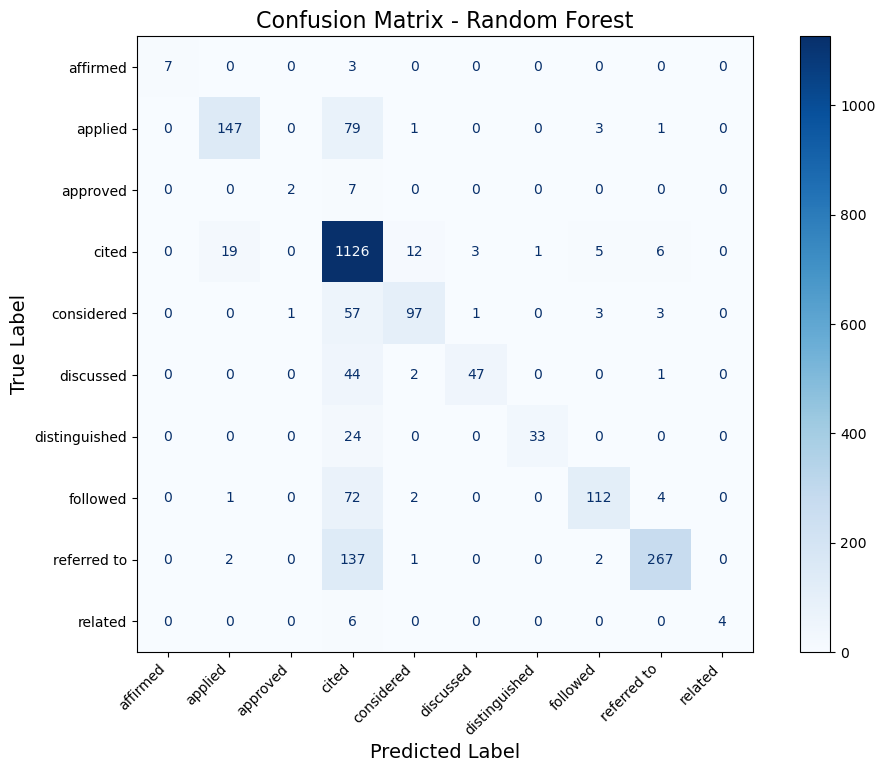

In [357]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_modified)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)

# Adjust figure size and label font
plt.figure(figsize=(12, 8))
disp_rf.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix - Random Forest", fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

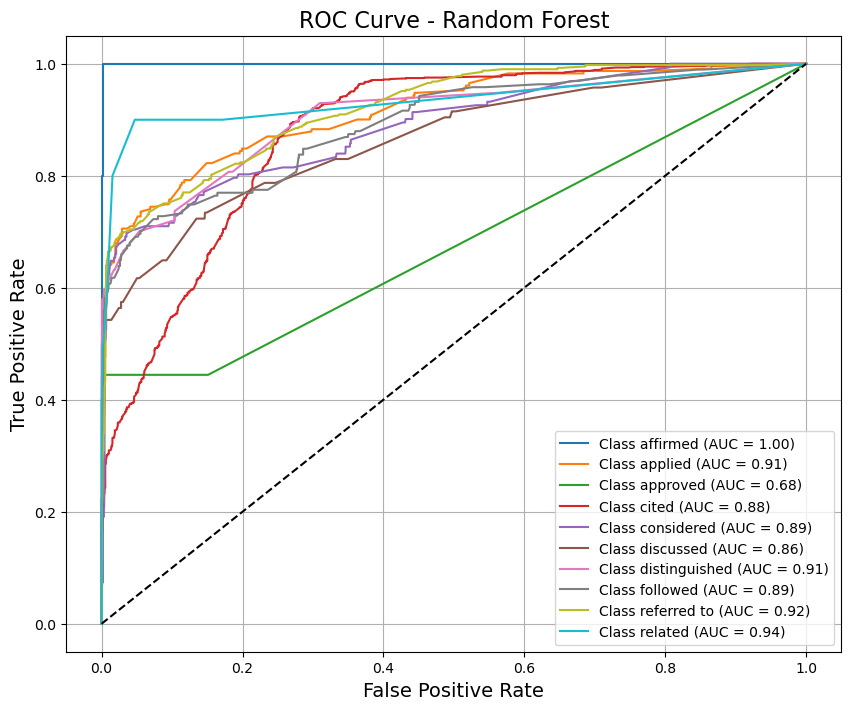

In [366]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Refit the Random Forest model to ensure it's trained
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Get the predicted probabilities for Random Forest
y_pred_rf_prob = rf.predict_proba(X_test)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_rf_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('ROC Curve - Random Forest', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid()
plt.show()


In [317]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

#No Penalty
logreg_balanced = LogisticRegression(max_iter=200, class_weight='balanced', penalty=None)
logreg_balanced.fit(X_train, y_train)
y_pred_balanced = logreg_balanced.predict(X_test)
print("Balanced Model Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nBalanced Model Classification Report:\n", classification_report(y_test, y_pred_balanced, target_names=label_encoder.classes_, zero_division=0))

# ===============================> BEST PERFORMING MODEL


Balanced Model Accuracy: 0.7142857142857143

Balanced Model Classification Report:
                precision    recall  f1-score   support

     affirmed       0.75      0.60      0.67        10
      applied       0.61      0.69      0.65       231
     approved       1.00      0.22      0.36         9
        cited       0.79      0.74      0.77      1172
   considered       0.63      0.67      0.65       162
    discussed       0.64      0.53      0.58        94
distinguished       0.78      0.63      0.70        57
     followed       0.65      0.63      0.64       191
  referred to       0.66      0.77      0.71       409
      related       1.00      0.40      0.57        10

     accuracy                           0.71      2345
    macro avg       0.75      0.59      0.63      2345
 weighted avg       0.72      0.71      0.71      2345



In [319]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression with default l2 penalty (Modified)
logreg_modified = LogisticRegression(max_iter=200, class_weight='balanced')

# Train the modified Logistic Regression model
logreg_modified.fit(X_train, y_train)

# Make predictions
y_pred_modified = logreg_modified.predict(X_test)

# Evaluate the model
print("Modified Model Accuracy:", accuracy_score(y_test, y_pred_modified))
print("\nModified Model Classification Report:\n", classification_report(y_test, y_pred_modified, target_names=label_encoder.classes_, zero_division=0))


Modified Model Accuracy: 0.48443496801705754

Modified Model Classification Report:
                precision    recall  f1-score   support

     affirmed       0.29      0.90      0.44        10
      applied       0.38      0.54      0.44       231
     approved       0.33      0.44      0.38         9
        cited       0.80      0.41      0.55      1172
   considered       0.32      0.54      0.40       162
    discussed       0.28      0.59      0.38        94
distinguished       0.33      0.72      0.45        57
     followed       0.33      0.50      0.40       191
  referred to       0.49      0.56      0.52       409
      related       0.33      0.60      0.43        10

     accuracy                           0.48      2345
    macro avg       0.39      0.58      0.44      2345
 weighted avg       0.59      0.48      0.50      2345



In [320]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Logistic Regression model
logreg_no_weight = LogisticRegression(
    max_iter=2000,           # Allow more iterations to ensure convergence
    solver='saga',           # Use the 'saga' solver for better compatibility
    class_weight=None        # No balancing for class imbalance
)

# Convert X_train and X_test to dense format (if sparse)
X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test

# Train the model
logreg_no_weight.fit(X_train_dense, y_train)

# Make predictions
y_pred_no_weight = logreg_no_weight.predict(X_test_dense)

# Evaluate the model
print("No Class Weights Model Accuracy:", accuracy_score(y_test, y_pred_no_weight))
print("\nNo Class Weights Classification Report:\n", classification_report(y_test, y_pred_no_weight, target_names=label_encoder.classes_, zero_division=0))


No Class Weights Model Accuracy: 0.5812366737739872

No Class Weights Classification Report:
                precision    recall  f1-score   support

     affirmed       0.00      0.00      0.00        10
      applied       0.66      0.19      0.29       231
     approved       0.00      0.00      0.00         9
        cited       0.56      0.95      0.71      1172
   considered       0.74      0.14      0.24       162
    discussed       1.00      0.05      0.10        94
distinguished       1.00      0.07      0.13        57
     followed       0.88      0.12      0.21       191
  referred to       0.63      0.37      0.46       409
      related       0.00      0.00      0.00        10

     accuracy                           0.58      2345
    macro avg       0.55      0.19      0.21      2345
 weighted avg       0.64      0.58      0.50      2345



In [323]:
# Store model accuracies
accuracies = [
    ("No Penalty Model", accuracy_score(y_test, y_pred_balanced)),
    ("Modified Model (L2 Penalty)", accuracy_score(y_test, y_pred_modified)),
    ("No Class Weights Model", accuracy_score(y_test, y_pred_no_weight))
]

# Find the best model
best_model = max(accuracies, key=lambda x: x[1])

# Print results
print("Model Accuracies:")
for name, acc in accuracies:
    print(f"{name}: {acc:.4f}")

print(f"\nBest Model: {best_model[0]} with Accuracy: {best_model[1]:.4f}")


Model Accuracies:
No Penalty Model: 0.7143
Modified Model (L2 Penalty): 0.4844
No Class Weights Model: 0.5812

Best Model: No Penalty Model with Accuracy: 0.7143


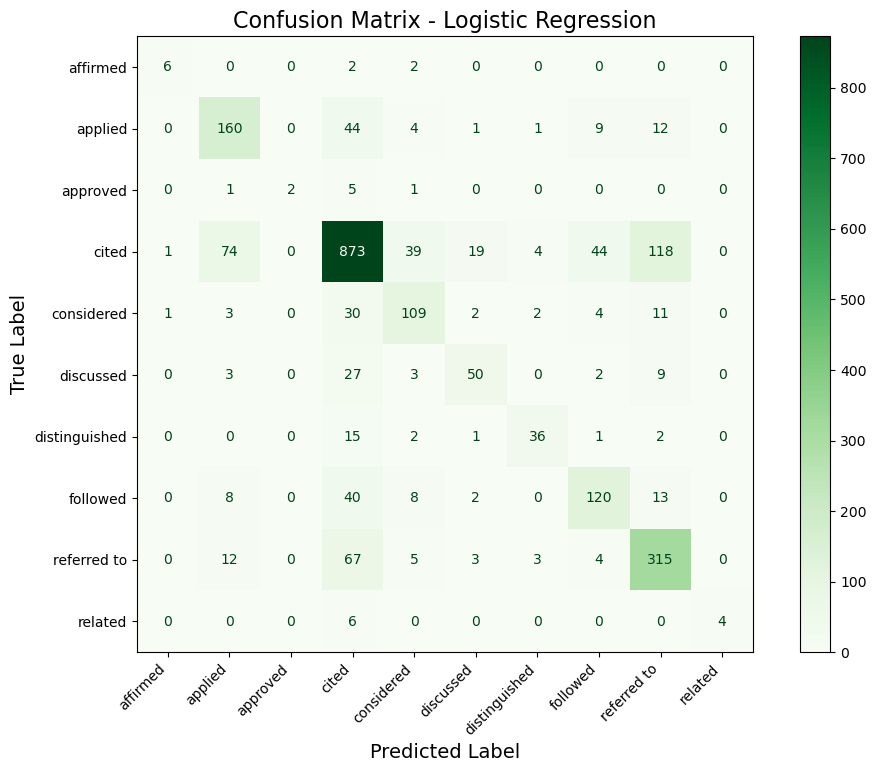

In [359]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_logreg = confusion_matrix(y_test, y_pred_balanced)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=label_encoder.classes_)

# Adjust figure size and label font
plt.figure(figsize=(12, 8))
disp_logreg.plot(cmap='Greens', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix - Logistic Regression", fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

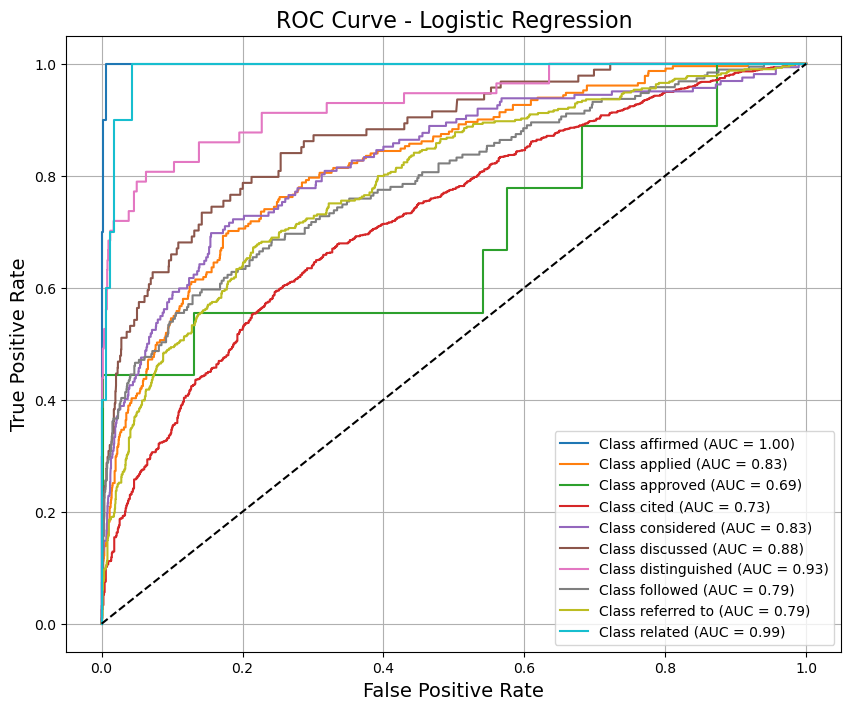

In [361]:
# Get the predicted probabilities for Logistic Regression
y_pred_logreg_prob = logreg_modified.predict_proba(X_test)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_logreg_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('ROC Curve - Logistic Regression', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid()
plt.show()


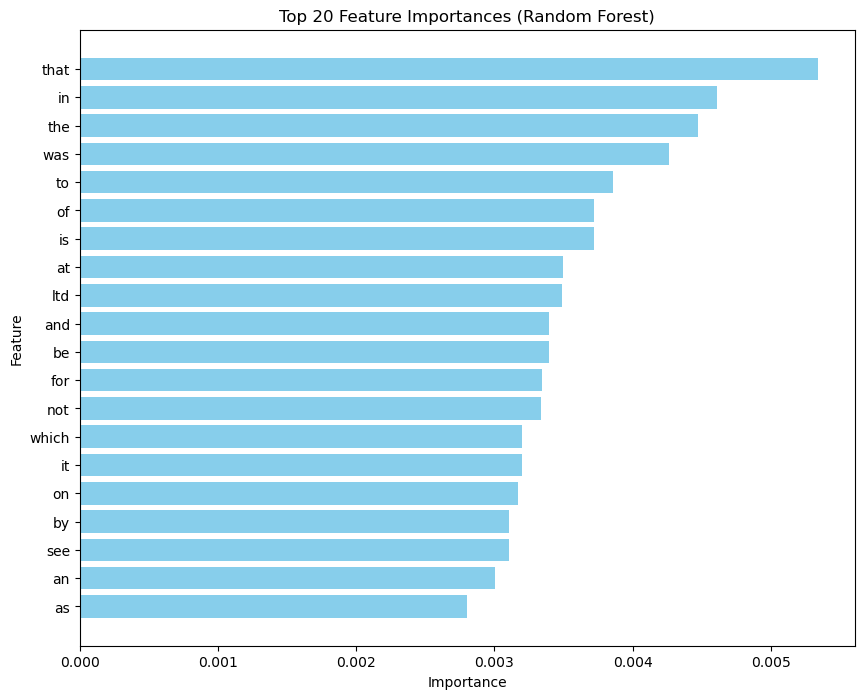

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Assuming `dataset` is already loaded and preprocessed
# Drop rows where 'case_text' or 'case_outcome' is missing
dataset = dataset.dropna(subset=['case_text', 'case_outcome'])

# Ensure all text data is of type string
dataset['case_text'] = dataset['case_text'].astype(str)

# Step 1: Fit the TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(dataset['case_text'])
y_train = dataset['case_outcome']

# Step 2: Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 3: Get feature importances
importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Step 4: Pair and sort feature importances
feature_importances = list(zip(feature_names, importances))
feature_importances = sorted(feature_importances, key=lambda x: x[1], reverse=True)

# Step 5: Select top 20 features
top_features = feature_importances[:20]
top_words, top_importances = zip(*top_features)

# Step 6: Plot the top features
plt.figure(figsize=(10, 8))
plt.barh(top_words, top_importances, color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()  # Reverse the order of features for better readability
plt.show()


In [373]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVM model
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)

# Train the SVM model
svm_model.fit(X_train, y_train)

# Predict the labels for the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Model Accuracy:", accuracy_svm)

# Classification Report (optional)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_, zero_division=0))


SVM Model Accuracy: 0.5343283582089552

Classification Report:
                precision    recall  f1-score   support

     affirmed       0.69      0.90      0.78        10
      applied       0.36      0.61      0.45       231
     approved       0.50      0.44      0.47         9
        cited       0.79      0.47      0.59      1172
   considered       0.36      0.58      0.45       162
    discussed       0.36      0.59      0.45        94
distinguished       0.58      0.67      0.62        57
     followed       0.39      0.56      0.46       191
  referred to       0.52      0.60      0.56       409
      related       0.80      0.40      0.53        10

     accuracy                           0.53      2345
    macro avg       0.54      0.58      0.54      2345
 weighted avg       0.62      0.53      0.55      2345



In [374]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
import numpy as np

# Initialize KMeans
kmeans = KMeans(n_clusters=len(np.unique(y_test)), random_state=42)

# Fit and predict
kmeans.fit(X_train)
y_pred_kmeans = kmeans.predict(X_test)

# Match clusters to true labels
from scipy.optimize import linear_sum_assignment

def map_clusters_to_labels(y_true, y_pred):
    """
    Maps KMeans cluster predictions to ground truth labels.
    """
    contingency_matrix = np.zeros((len(np.unique(y_true)), len(np.unique(y_pred))))
    for true_label, pred_label in zip(y_true, y_pred):
        contingency_matrix[true_label][pred_label] += 1
    row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
    return col_ind

mapped_labels = map_clusters_to_labels(y_test, y_pred_kmeans)
mapped_predictions = [mapped_labels[pred] for pred in y_pred_kmeans]

# Calculate accuracy
accuracy = accuracy_score(y_test, mapped_predictions)

print("KMeans Accuracy (mapped to labels):", accuracy)


KMeans Accuracy (mapped to labels): 0.08912579957356077
